# Machine Learning Forecasting

## Objective

This notebook evaluates whether machine learning models can improve forecasting performance beyond traditional statistical forecasting methods.

Previous notebooks showed that demand is primarily driven by strong yearly seasonality and long-term growth. Holt-Winters Exponential Smoothing achieved strong performance and serves as the statistical benchmark for the machine learning models tested here.

The focus of this notebook is to:

- engineer lag, rolling, calendar, and business features
- train machine learning models using a temporal validation split
- detect and remove target leakage
- compare model performance against the statistical benchmark
- interpret feature importance from a business forecasting perspective


## 1. Setup

In [3]:
# Core libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# File paths
from pathlib import Path

# Modeling
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

# Evaluation
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)

## 2. Data Preparation

The machine learning models use the forecasting base dataset at the original product-market-month grain. This preserves product, market, lifecycle, supply, inventory, and demand signal information that was not available in the aggregated statistical forecasting notebook.


In [5]:
project_root = Path.cwd().parent
data_path = project_root / "data" / "processed" / "vw_forecasting_base.csv"

# SSMS exports may not include headers, so column names are defined explicitly.
columns = [
    "month",
    "product_id",
    "market_id",
    "category",
    "brand",
    "lifecycle_stage",
    "region",
    "lead_time_months",
    "strategic_priority",
    "actual_demand_units",
    "promo_flag",
    "campaign_intensity",
    "demand_signal_quality",
    "available_supply_units",
    "production_capacity_units",
    "supply_constraint_flag",
    "actual_shipped_units",
    "unfulfilled_demand_units",
    "service_level_pct",
    "ending_inventory_units",
    "inventory_risk_status"
]

df = pd.read_csv(
    data_path,
    header=None,
    names=columns,
    sep=";",
    keep_default_na=False
)

df.head()

,month,product_id,market_id,category,brand,lifecycle_stage,region,lead_time_months,strategic_priority,actual_demand_units,...,campaign_intensity,demand_signal_quality,available_supply_units,production_capacity_units,supply_constraint_flag,actual_shipped_units,unfulfilled_demand_units,service_level_pct,ending_inventory_units,inventory_risk_status
0,1/1/2021,PRD001,MKT001,Fragrance,Aurelian,Core,WE,1,3,1454,...,1.0,High,12250,19533,1,950,504,0.6534,1418,Normal
1,1/1/2021,PRD001,MKT002,Fragrance,Aurelian,Core,WE,1,5,1592,...,1.0,High,12250,19533,1,1128,464,0.7085,1172,Normal
2,1/1/2021,PRD001,MKT003,Fragrance,Aurelian,Core,WE,2,4,1536,...,1.0,High,12250,19533,1,1086,450,0.7070,1227,Normal
3,1/1/2021,PRD001,MKT004,Fragrance,Aurelian,Core,NA,2,4,1200,...,1.0,Medium,12250,19533,1,946,254,0.7883,1095,Normal
4,1/1/2021,PRD001,MKT005,Fragrance,Aurelian,Core,NA,3,2,843,...,1.0,High,12250,19533,1,720,123,0.8541,809,Normal


In [6]:
rows, cols = df.shape
print(f"Rows: {rows:,} | Columns: {cols}")

Rows: 17,280 | Columns: 21


In [7]:
df.describe()

,lead_time_months,strategic_priority,actual_demand_units,promo_flag,campaign_intensity,available_supply_units,production_capacity_units,supply_constraint_flag,actual_shipped_units,unfulfilled_demand_units,service_level_pct,ending_inventory_units
count,17280.000000,17280.000000,17280.000000,17280.000000,17280.000000,17280.00000,17280.000000,17280.000000,17280.000000,17280.000000,17280.000000,17280.000000
mean,2.666667,3.333333,1310.963600,0.127083,1.154167,15229.24375,17255.884722,0.430556,1140.506308,170.457292,4.797783,2482.983333
std,1.027432,1.433762,957.199488,0.333076,0.179656,8642.63890,10812.553231,0.495168,746.364198,303.961595,4.537714,2062.686166
min,1.000000,1.000000,0.000000,0.000000,1.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.368400,0.000000
25%,2.000000,2.000000,691.000000,0.000000,1.000000,9498.50000,10305.000000,0.000000,647.000000,0.000000,0.839775,1121.000000
50%,3.000000,4.000000,1108.000000,0.000000,1.100000,14307.00000,15982.500000,0.000000,1006.000000,37.000000,0.962800,1921.000000
75%,3.250000,4.250000,1691.000000,0.000000,1.225000,19475.75000,21796.750000,1.000000,1490.000000,218.000000,10.000000,3251.000000
max,4.000000,5.000000,11134.000000,1.000000,1.450000,74908.00000,111255.000000,1.000000,8264.000000,4159.000000,10.000000,16616.000000


In [8]:
# Convert month to datetime for chronological sorting and temporal splitting.
df["month"] = pd.to_datetime(
    df["month"],
    format="%d/%m/%Y",
    dayfirst=True
)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17280 entries, 0 to 17279
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   month                      17280 non-null  datetime64[ns]
 1   product_id                 17280 non-null  object        
 2   market_id                  17280 non-null  object        
 3   category                   17280 non-null  object        
 4   brand                      17280 non-null  object        
 5   lifecycle_stage            17280 non-null  object        
 6   region                     17280 non-null  object        
 7   lead_time_months           17280 non-null  int64         
 8   strategic_priority         17280 non-null  int64         
 9   actual_demand_units        17280 non-null  int64         
 10  promo_flag                 17280 non-null  int64         
 11  campaign_intensity         17280 non-null  float64       
 12  dema

## 3. Feature Engineering

The feature engineering strategy translates the demand patterns found during EDA into model-ready predictors:

- calendar features capture seasonality
- lag features capture historical demand behavior
- rolling features capture recent trend and local demand level
- rolling standard deviations capture volatility

All lag and rolling features are created within each product-market time series to avoid mixing demand histories across different business entities.


In [10]:
# Sort each product-market time series chronologically before creating lag features.
df = (
    df.sort_values(["product_id", "market_id", "month"])
      .reset_index(drop=True)
)

df.head()

,month,product_id,market_id,category,brand,lifecycle_stage,region,lead_time_months,strategic_priority,actual_demand_units,...,campaign_intensity,demand_signal_quality,available_supply_units,production_capacity_units,supply_constraint_flag,actual_shipped_units,unfulfilled_demand_units,service_level_pct,ending_inventory_units,inventory_risk_status
0,2021-01-01,PRD001,MKT001,Fragrance,Aurelian,Core,WE,1,3,1454,...,1.00,High,12250,19533,1,950,504,0.6534,1418,Normal
1,2021-02-01,PRD001,MKT001,Fragrance,Aurelian,Core,WE,1,3,1518,...,1.10,Medium,18847,17977,0,1352,166,0.8906,1711,Normal
2,2021-03-01,PRD001,MKT001,Fragrance,Aurelian,Core,WE,1,3,1579,...,1.10,Low,17757,19989,1,1393,186,0.8822,1662,Normal
3,2021-04-01,PRD001,MKT001,Fragrance,Aurelian,Core,WE,1,3,1413,...,1.00,Medium,18542,18876,0,1290,123,0.9130,1251,Normal
4,2021-05-01,PRD001,MKT001,Fragrance,Aurelian,Core,WE,1,3,1434,...,1.15,High,19256,20442,1,1360,74,0.9484,1310,Normal


### Calendar Features

In [12]:
df["year"] = df["month"].dt.year
df["month_number"] = df["month"].dt.month
df["quarter"] = df["month"].dt.quarter

### Lag Features

In [14]:
# Lag features use previous demand from the same product-market time series.
for lag in [1, 3, 6, 12]:
    df[f"lag_{lag}"] = (
        df.groupby(["product_id", "market_id"])["actual_demand_units"]
          .shift(lag)
    )

### Rolling Mean Features

In [16]:
# Shift before rolling to prevent using the current month's demand to predict itself.
df["rolling_mean_3"] = (
    df.groupby(["product_id", "market_id"])["actual_demand_units"]
      .transform(lambda x: x.shift(1).rolling(3).mean())
)

df["rolling_mean_6"] = (
    df.groupby(["product_id", "market_id"])["actual_demand_units"]
      .transform(lambda x: x.shift(1).rolling(6).mean())
)

### Rolling Volatility Features

In [18]:
df["rolling_std_3"] = (
    df.groupby(["product_id", "market_id"])["actual_demand_units"]
      .transform(lambda x: x.shift(1).rolling(3).std())
)

df["rolling_std_6"] = (
    df.groupby(["product_id", "market_id"])["actual_demand_units"]
      .transform(lambda x: x.shift(1).rolling(6).std())
)

## 4. Feature Validation

Lag and rolling features naturally introduce null values at the beginning of each product-market time series. These rows are removed before modeling because not all historical features are available for them.


In [20]:
engineered_features = [
    "lag_1",
    "lag_3",
    "lag_6",
    "lag_12",
    "rolling_mean_3",
    "rolling_mean_6",
    "rolling_std_3",
    "rolling_std_6"
]

df[engineered_features].isna().sum()

lag_1              288
lag_3              864
lag_6             1728
lag_12            3456
rolling_mean_3     864
rolling_mean_6    1728
rolling_std_3      864
rolling_std_6     1728
dtype: int64

In [21]:
df_model = df.dropna(subset=engineered_features).copy()

print(f"Original shape: {df.shape}")
print(f"Modeling shape: {df_model.shape}")

Original shape: (17280, 32)
Modeling shape: (13824, 32)


In [22]:
df_model[
    [
        "month",
        "product_id",
        "market_id",
        "actual_demand_units",
        "lag_1",
        "lag_12",
        "rolling_mean_3",
        "rolling_std_3"
    ]
].head(15)

,month,product_id,market_id,actual_demand_units,lag_1,lag_12,rolling_mean_3,rolling_std_3
12,2022-01-01,PRD001,MKT001,1191,3464.0,1454.0,2745.000000,865.055490
13,2022-02-01,PRD001,MKT001,1414,1191.0,1518.0,2547.000000,1198.404356
14,2022-03-01,PRD001,MKT001,1312,1414.0,1579.0,2023.000000,1252.913804
15,2022-04-01,PRD001,MKT001,1364,1312.0,1413.0,1305.666667,111.634821
16,2022-05-01,PRD001,MKT001,1413,1364.0,1434.0,1363.333333,51.003268
17,2022-06-01,PRD001,MKT001,1735,1413.0,1353.0,1363.000000,50.507425
18,2022-07-01,PRD001,MKT001,1190,1735.0,1380.0,1504.000000,201.546521
19,2022-08-01,PRD001,MKT001,1520,1190.0,1286.0,1446.000000,273.994525
20,2022-09-01,PRD001,MKT001,1372,1520.0,1526.0,1481.666667,274.514723
21,2022-10-01,PRD001,MKT001,2079,1372.0,1785.0,1360.666667,165.291661


## 5. Categorical Feature Encoding

Categorical variables are one-hot encoded so they can be used by tree-based machine learning models. This is appropriate here because the dataset is relatively small and the categorical cardinality is manageable.


In [24]:
categorical_cols = [
    "product_id",
    "market_id",
    "category",
    "brand",
    "lifecycle_stage",
    "region",
    "demand_signal_quality",
    "inventory_risk_status"
]

df_model[categorical_cols].nunique()

product_id               24
market_id                12
category                  4
brand                     6
lifecycle_stage           3
region                    5
demand_signal_quality     3
inventory_risk_status     3
dtype: int64

In [25]:
df_model_encoded = pd.get_dummies(
    df_model,
    columns=categorical_cols,
    drop_first=True
)

print(f"Before encoding: {df_model.shape}")
print(f"After encoding:  {df_model_encoded.shape}")

Before encoding: (13824, 32)
After encoding:  (13824, 76)


## 6. Modeling Dataset and Leakage Prevention

The target variable is `actual_demand_units`.

Some columns must be excluded because they are either identifiers/date fields or future outcome variables. In particular, `actual_shipped_units`, `unfulfilled_demand_units`, and `service_level_pct` are not known at forecast creation time and would introduce target leakage.


In [27]:
target = "actual_demand_units"

cols_to_exclude = [
    "actual_demand_units",
    "month",

    # Leakage features: future operational outcomes, not valid predictors.
    "actual_shipped_units",
    "unfulfilled_demand_units",
    "service_level_pct"
]

feature_cols = [
    col
    for col in df_model_encoded.columns
    if col not in cols_to_exclude
]

X = df_model_encoded[feature_cols]
y = df_model_encoded[target]

print(f"Feature matrix shape: {X.shape}")
print(f"Target shape: {y.shape}")

Feature matrix shape: (13824, 71)
Target shape: (13824,)


## 7. Temporal Train/Test Split

A random train/test split would leak future information into training. Instead, the data is split chronologically:

- Training period: all available observations before 2025
- Test period: 2025 observations

This simulates the real forecasting scenario: using historical information to predict future demand.


In [29]:
train = df_model_encoded[
    df_model_encoded["month"] < "2025-01-01"
]

test = df_model_encoded[
    df_model_encoded["month"] >= "2025-01-01"
]

X_train = train[feature_cols]
y_train = train[target]

X_test = test[feature_cols]
y_test = test[target]

print(f"Train rows: {len(X_train):,}")
print(f"Test rows:  {len(X_test):,}")

Train rows: 10,368
Test rows:  3,456


## 8. Random Forest Regressor

Random Forest is used as the first machine learning benchmark. It can capture nonlinear relationships and feature interactions, but it does not naturally extrapolate trend as directly as classical time series models.


In [31]:
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

rf_predictions = rf.predict(X_test)

In [32]:
rf_mae = mean_absolute_error(
    y_true=y_test,
    y_pred=rf_predictions
)

rf_mse = mean_squared_error(
    y_true=y_test,
    y_pred=rf_predictions
)

rf_mape = mean_absolute_percentage_error(
    y_true=y_test,
    y_pred=rf_predictions
)

print(f"RF MAE:  {rf_mae:,.2f}")
print(f"RF MSE:  {rf_mse:,.2f}")
print(f"RF MAPE: {rf_mape:.4f}")

RF MAE:  203.80
RF MSE:  110,035.47
RF MAPE: 0.1271


In [33]:
rf_feature_importance = (
    pd.DataFrame({
        "feature": X_train.columns,
        "importance": rf.feature_importances_
    })
    .sort_values("importance", ascending=False)
)

rf_feature_importance.head(15)

,feature,importance
14,lag_12,0.821860
11,lag_1,0.070326
5,production_capacity_units,0.027757
15,rolling_mean_3,0.017364
16,rolling_mean_6,0.015217
2,promo_flag,0.014708
4,available_supply_units,0.007509
9,month_number,0.005118
13,lag_6,0.004398
12,lag_3,0.002933


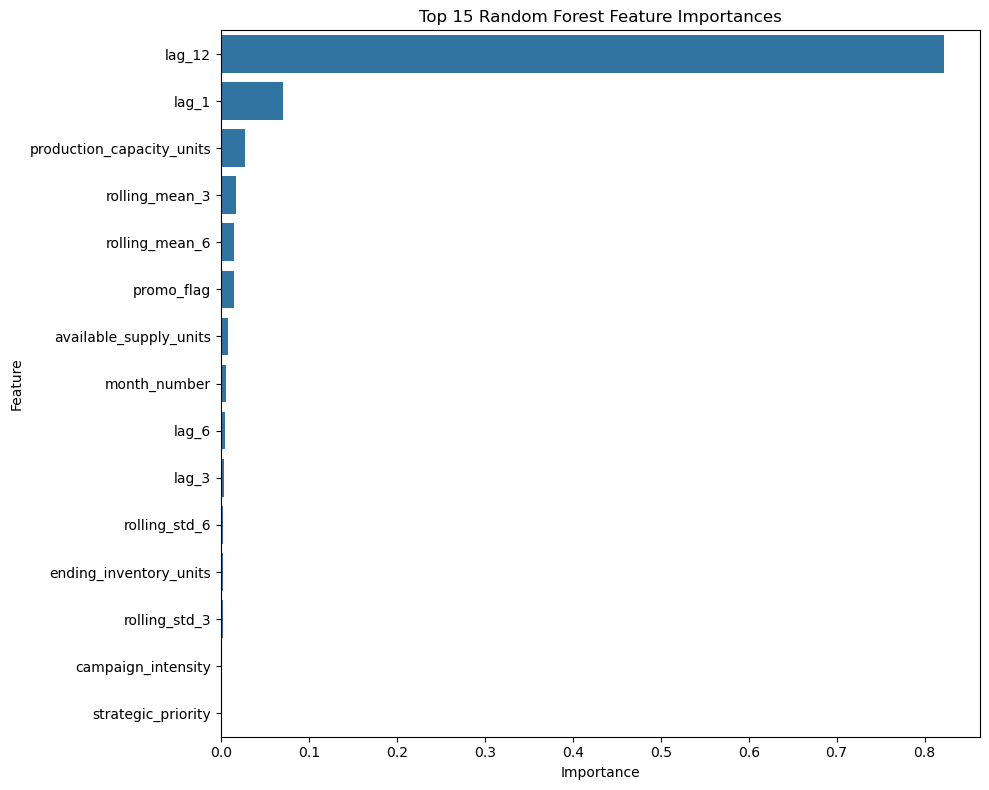

In [34]:
plt.figure(figsize=(10, 8))

sns.barplot(
    data=rf_feature_importance.head(15),
    x="importance",
    y="feature"
)

plt.title("Top 15 Random Forest Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

### Random Forest Interpretation

After removing leakage variables, Random Forest performance is substantially worse than the Holt-Winters benchmark. Feature importance shows that `lag_12` dominates the model, reinforcing the finding that yearly seasonality is the strongest predictor of future demand.

This indicates that the model is learning the same seasonal structure identified during EDA, but it is not modeling the overall trend as effectively as Holt-Winters.


## 9. XGBoost Regressor

XGBoost is evaluated as a stronger tree-based model. It can capture nonlinear patterns and interactions more effectively than Random Forest, making it a useful final machine learning challenger against the statistical forecasting benchmark.


In [37]:
xgb = XGBRegressor(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

xgb.fit(X_train, y_train)

xgb_predictions = xgb.predict(X_test)

In [38]:
xgb_mae = mean_absolute_error(
    y_true=y_test,
    y_pred=xgb_predictions
)

xgb_mse = mean_squared_error(
    y_true=y_test,
    y_pred=xgb_predictions
)

xgb_mape = mean_absolute_percentage_error(
    y_true=y_test,
    y_pred=xgb_predictions
)

print(f"XGB MAE:  {xgb_mae:,.2f}")
print(f"XGB MSE:  {xgb_mse:,.2f}")
print(f"XGB MAPE: {xgb_mape:.4f}")

XGB MAE:  188.00
XGB MSE:  96,485.12
XGB MAPE: 0.1158


In [39]:
xgb_feature_importance = (
    pd.DataFrame({
        "feature": X_train.columns,
        "importance": xgb.feature_importances_
    })
    .sort_values("importance", ascending=False)
)

xgb_feature_importance.head(15)

,feature,importance
14,lag_12,0.457995
11,lag_1,0.094994
2,promo_flag,0.037082
5,production_capacity_units,0.036544
9,month_number,0.033374
16,rolling_mean_6,0.026097
15,rolling_mean_3,0.024779
3,campaign_intensity,0.016595
55,category_Skincare,0.012819
53,category_Fragrance,0.012741


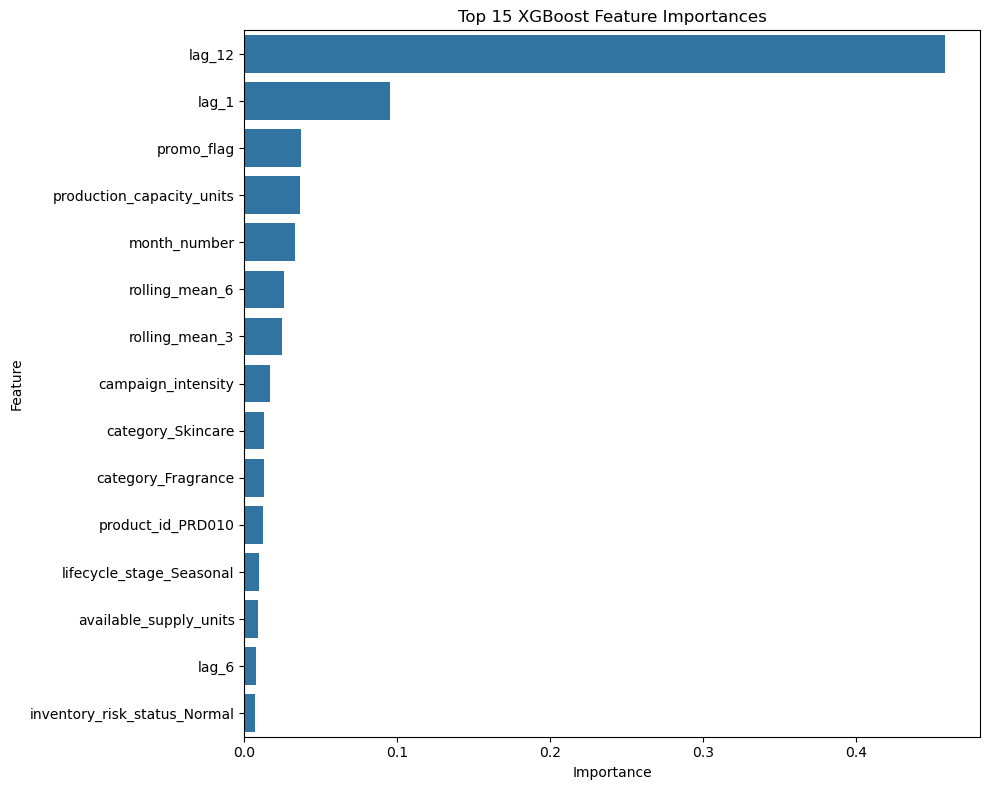

In [40]:
plt.figure(figsize=(10, 8))

sns.barplot(
    data=xgb_feature_importance.head(15),
    x="importance",
    y="feature"
)

plt.title("Top 15 XGBoost Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

### XGBoost Interpretation

XGBoost improves on Random Forest but still does not outperform the best statistical forecasting model. Its feature importance again identifies `lag_12` as the dominant predictor, confirming that the core demand signal is primarily seasonal.

The model uses additional features such as recent demand, promotions, production capacity, campaign intensity, and category indicators, but these do not provide enough incremental value to beat Holt-Winters.


## 10. Final Model Comparison

In [43]:
model_comparison = pd.DataFrame({
    "model": [
        "Naive Forecast",
        "Seasonal Naive",
        "XGBoost",
        "Random Forest",
        "Seasonal Naive + Trend Adjustment",
        "Holt-Winters Exponential Smoothing"
    ],
    "mape": [
        0.5897,
        0.1155,
        xgb_mape,
        rf_mape,
        0.0203,
        0.0139
    ]
})

model_comparison["mape_pct"] = model_comparison["mape"] * 100
model_comparison = model_comparison.sort_values("mape")

model_comparison

,model,mape,mape_pct
5,Holt-Winters Exponential Smoothing,0.013900,1.390000
4,Seasonal Naive + Trend Adjustment,0.020300,2.030000
1,Seasonal Naive,0.115500,11.550000
2,XGBoost,0.115819,11.581854
3,Random Forest,0.127064,12.706415
0,Naive Forecast,0.589700,58.970000


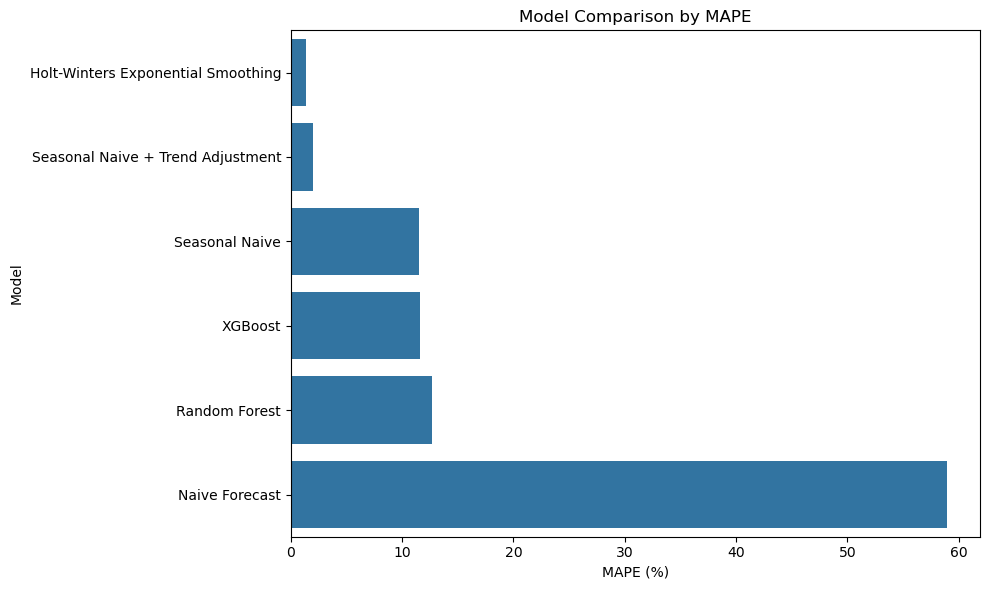

In [44]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=model_comparison,
    x="mape_pct",
    y="model"
)

plt.title("Model Comparison by MAPE")
plt.xlabel("MAPE (%)")
plt.ylabel("Model")
plt.tight_layout()
plt.show()

# Conclusions

This notebook evaluated whether machine learning models could improve forecasting performance beyond the statistical models developed previously.

The results show that machine learning did not outperform the best statistical forecasting approach. Holt-Winters Exponential Smoothing remained the strongest model, achieving a MAPE of 1.39%, compared with 11.58% for XGBoost and 12.71% for Random Forest.

The feature importance analysis provides the key explanation: both machine learning models relied heavily on `lag_12`, confirming that yearly seasonality is the dominant predictive signal. This aligns with the exploratory analysis and the strong performance of seasonal statistical models.

A target leakage issue was also identified and corrected. Initial Random Forest results appeared unrealistically strong because future outcome variables such as shipped units and unfulfilled demand were included as predictors. Removing those variables produced a realistic modeling setup and a more credible comparison.

The main conclusion is that this demand forecasting problem is highly structured and primarily driven by trend and seasonality. In this context, a simpler and more interpretable statistical model outperforms more complex machine learning approaches.

From a business perspective, Holt-Winters is the recommended forecasting model because it provides the best accuracy while remaining transparent, explainable, and operationally appropriate.
